# AI-2002 Artificial Intelligence Lab — Assignments 10 & 11
## Supervised & Unsupervised Learning Tasks

**Tasks Overview:**
- **Task 1:** Credit Card Fraud Detection (Classification)
- **Task 2:** House Price Prediction (Regression)
- **Task 3:** Customer Segmentation (Clustering)

---

> **Dataset Setup Instructions:**
> - **Task 1:** Download `creditcard.csv` from [Kaggle - Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) and place it in your working directory.
> - **Task 2:** Download `train.csv` from [Kaggle - House Prices](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) and place it in your working directory.
> - **Task 3:** Download `marketing_campaign.csv` from [Kaggle - Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis) and place it in your working directory.


## Install & Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("All libraries imported successfully!")


All libraries imported successfully!


---
# Task 1: Credit Card Fraud Detection (Classification)
**Dataset:** Credit Card Fraud Detection — Kaggle  
**Models:** Logistic Regression, Random Forest  
**Goal:** Detect fraudulent transactions on a highly imbalanced dataset.


### Step 1 — Load Dataset

In [2]:
df1 = pd.read_csv('creditcard.csv')
print("Shape:", df1.shape)
print("\nClass distribution:")
print(df1['Class'].value_counts())
print(f"\nFraud percentage: {df1['Class'].mean()*100:.4f}%")
df1.head()


Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Step 2 — Handle Class Imbalance (SMOTE Oversampling)

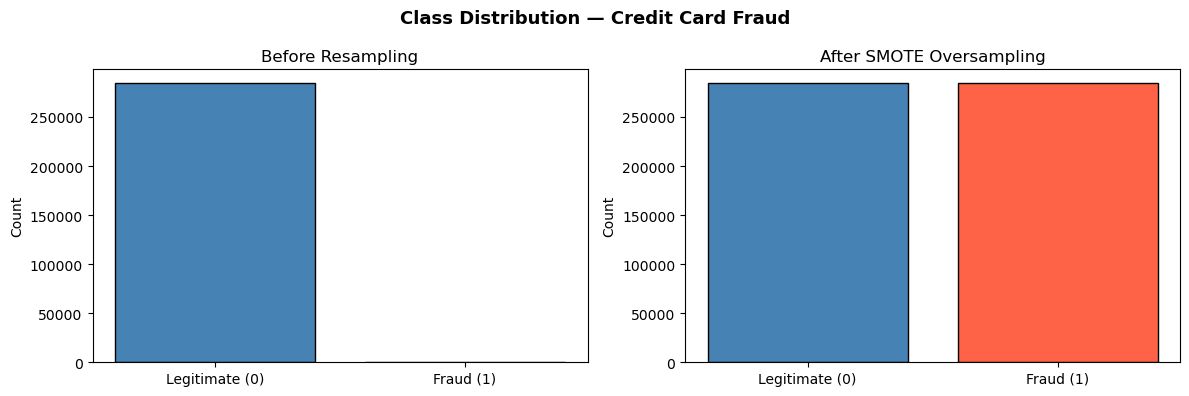

Resampled dataset shape: (568630, 30)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
            df1['Class'].value_counts().values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Before Resampling')
axes[0].set_ylabel('Count')

X1 = df1.drop('Class', axis=1)
y1 = df1['Class']

smote = SMOTE(random_state=42)
X1_res, y1_res = smote.fit_resample(X1, y1)

axes[1].bar(['Legitimate (0)', 'Fraud (1)'],
            pd.Series(y1_res).value_counts().sort_index().values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('After SMOTE Oversampling')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution — Credit Card Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Resampled dataset shape: {X1_res.shape}")


### Step 3 — Feature Scaling

In [4]:
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1_res)
print("Feature scaling applied (StandardScaler)")
print(f"Mean ≈ {X1_scaled.mean():.4f}, Std ≈ {X1_scaled.std():.4f}")


Feature scaling applied (StandardScaler)
Mean ≈ -0.0000, Std ≈ 1.0000


### Step 4 — Train/Test Split (70/30)

In [5]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1_scaled, y1_res, test_size=0.30, random_state=42, stratify=y1_res)

print(f"Training samples : {X1_train.shape[0]}")
print(f"Testing  samples : {X1_test.shape[0]}")


Training samples : 398041
Testing  samples : 170589


### Step 5 — Train Models

In [6]:
lr1 = LogisticRegression(max_iter=1000, random_state=42)
lr1.fit(X1_train, y1_train)
y1_pred_lr = lr1.predict(X1_test)

rf1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf1.fit(X1_train, y1_train)
y1_pred_rf = rf1.predict(X1_test)

print("Both models trained!")


Both models trained!


### Step 6 — Evaluation & Model Comparison

In [7]:
def classification_metrics(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall'   : round(recall_score(y_true, y_pred), 4),
        'F1-Score' : round(f1_score(y_true, y_pred), 4),
    }

results1 = pd.DataFrame([
    classification_metrics(y1_test, y1_pred_lr, 'Logistic Regression'),
    classification_metrics(y1_test, y1_pred_rf, 'Random Forest'),
])
print("=" * 55)
print("         MODEL COMPARISON — TASK 1")
print("=" * 55)
print(results1.to_string(index=False))
print("=" * 55)
best1 = results1.loc[results1['F1-Score'].idxmax(), 'Model']
print(f"\nBest model for imbalanced data (F1): {best1}")


         MODEL COMPARISON — TASK 1
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9802     0.9910  0.9692    0.9800
      Random Forest    0.9998     0.9997  1.0000    0.9998

Best model for imbalanced data (F1): Random Forest


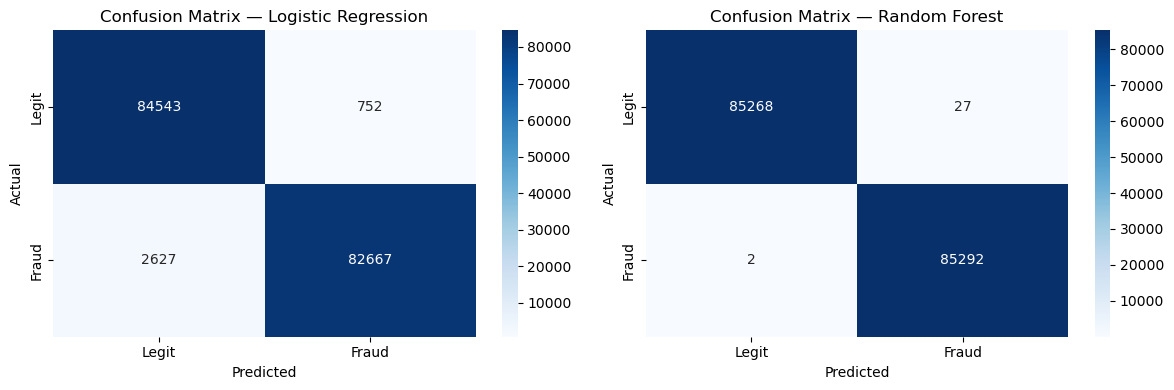

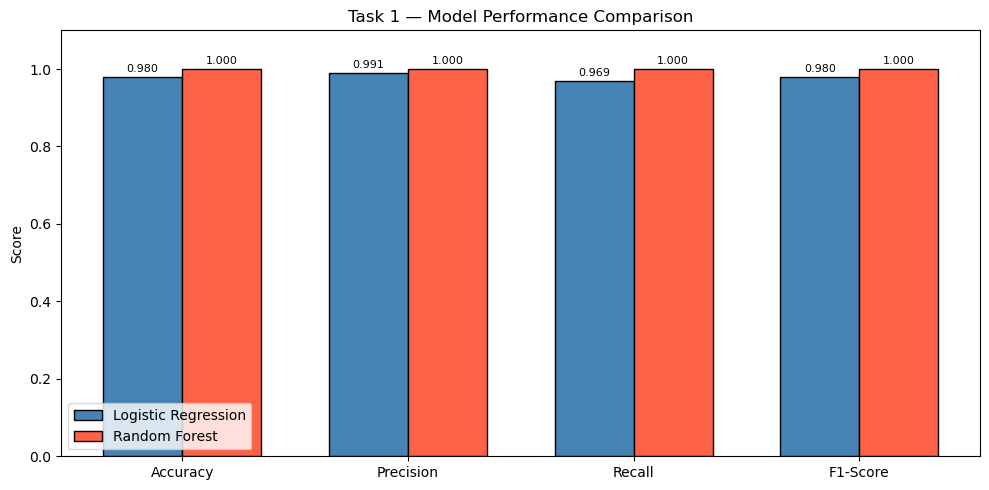

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title in zip(axes,
                              [y1_pred_lr, y1_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y1_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, results1[results1['Model']=='Logistic Regression'][metrics].values[0],
               width, label='Logistic Regression', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, results1[results1['Model']=='Random Forest'][metrics].values[0],
               width, label='Random Forest', color='tomato', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Task 1 — Model Performance Comparison')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()


---
# Task 2: House Price Prediction (Regression)
**Dataset:** House Prices — Advanced Regression Techniques — Kaggle  
**Models:** Linear Regression, Decision Tree Regressor  
**Goal:** Predict the sale price of houses.


### Step 1 — Load Dataset

In [17]:
df2 = pd.read_csv('train.csv')
print("Shape:", df2.shape)
print("\nMissing values (top 10):")
print(df2.isnull().sum().sort_values(ascending=False).head(10))
df2[['SalePrice']].describe()


Shape: (136, 81)

Missing values (top 10):
PoolQC          136
Alley           128
MiscFeature     126
Fence           106
MasVnrType       81
FireplaceQu      69
LotFrontage      23
GarageType       10
GarageYrBlt      10
GarageFinish     10
dtype: int64


,SalePrice
count,135.000000
mean,174295.851852
std,69845.487384
min,40000.000000
25%,129500.000000
50%,157000.000000
75%,206250.000000
max,438780.000000


### Step 2 — Encode Categorical Variables

In [23]:
le2 = LabelEncoder()
for col in cat_cols2:
    df2_clean[col] = le2.fit_transform(df2_clean[col].astype(str))

print(f"Encoded {len(cat_cols2)} categorical columns")
print("Dataset shape after encoding:", df2_clean.shape)


Encoded 37 categorical columns
Dataset shape after encoding: (136, 75)


### Step 3 — Feature Scaling & Train/Test Split

In [42]:
df2_clean = df2.copy()

df2_clean.dropna(subset=['SalePrice'], inplace=True)


thresh = len(df2_clean) * 0.5
df2_clean.dropna(thresh=thresh, axis=1, inplace=True)


num_cols = df2_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'SalePrice' in num_cols:
    num_cols.remove('SalePrice')

for col in num_cols:
    df2_clean[col] = df2_clean[col].fillna(df2_clean[col].median())


cat_cols = df2_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if not df2_clean[col].mode().empty:
        df2_clean[col] = df2_clean[col].fillna(df2_clean[col].mode()[0])


df2_clean = pd.get_dummies(df2_clean, columns=cat_cols, drop_first=True)


X2 = df2_clean.drop(columns=[c for c in ['Id', 'SalePrice'] if c in df2_clean.columns])
y2 = df2_clean['SalePrice']


print(f"NaNs in X2: {X2.isnull().sum().sum()}") 
print(f"NaNs in y2: {y2.isnull().sum()}") 


X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=42)

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

print(f"Cleaned training shape: {X2_train_sc.shape}")

NaNs in X2: 0
NaNs in y2: 0
Cleaned training shape: (94, 173)


### Step 4 — Train Models

In [31]:
linreg = LinearRegression()
linreg.fit(X2_train_sc, y2_train)
y2_pred_lr = linreg.predict(X2_test_sc)

dtr = DecisionTreeRegressor(random_state=42, max_depth=10)
dtr.fit(X2_train_sc, y2_train)
y2_pred_dtr = dtr.predict(X2_test_sc)

print("Both models trained!")


Both models trained!


### Step 5 — Evaluation & Model Comparison

In [32]:
def regression_metrics(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'Model': model_name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}

results2 = pd.DataFrame([
    regression_metrics(y2_test, y2_pred_lr,  'Linear Regression'),
    regression_metrics(y2_test, y2_pred_dtr, 'Decision Tree Regressor'),
])
print("=" * 50)
print("      MODEL COMPARISON — TASK 2")
print("=" * 50)
print(results2.to_string(index=False))
print("=" * 50)
best2 = results2.loc[results2['RMSE'].idxmin(), 'Model']
print(f"\nBest model (lowest RMSE): {best2}")


      MODEL COMPARISON — TASK 2
                  Model      MAE     RMSE
      Linear Regression 35927.15 45834.76
Decision Tree Regressor 33445.84 51327.51

Best model (lowest RMSE): Linear Regression


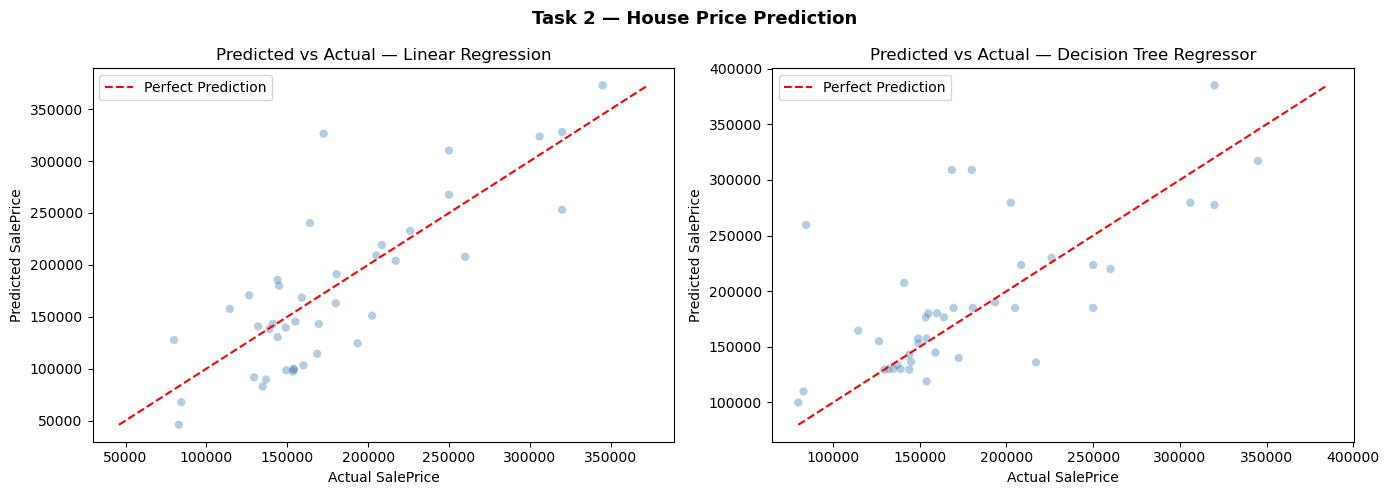

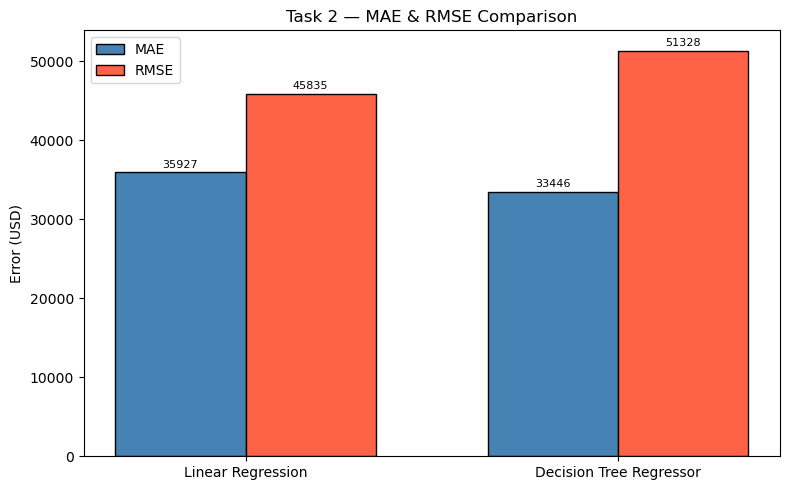

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes,
                              [y2_pred_lr, y2_pred_dtr],
                              ['Linear Regression', 'Decision Tree Regressor']):
    ax.scatter(y2_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none')
    mn, mx = min(y2_test.min(), y_pred.min()), max(y2_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual SalePrice')
    ax.set_ylabel('Predicted SalePrice')
    ax.set_title(f'Predicted vs Actual — {title}')
    ax.legend()
plt.suptitle('Task 2 — House Price Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
x2 = np.arange(2)
w = 0.35
b1 = ax.bar(x2 - w/2, results2['MAE'],  w, label='MAE',  color='steelblue', edgecolor='black')
b2 = ax.bar(x2 + w/2, results2['RMSE'], w, label='RMSE', color='tomato',    edgecolor='black')
ax.set_xticks(x2)
ax.set_xticklabels(results2['Model'])
ax.set_ylabel('Error (USD)')
ax.set_title('Task 2 — MAE & RMSE Comparison')
ax.legend()
ax.bar_label(b1, fmt='%.0f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.0f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()


---
# Task 3: Customer Segmentation (Unsupervised — K-Means Clustering)
**Dataset:** Customer Personality Analysis — Kaggle  
**Algorithm:** K-Means with Elbow Method  
**Goal:** Segment customers into meaningful groups.


### Step 1 — Load Dataset & Select Relevant Features

In [34]:
df3 = pd.read_csv('marketing_campaign.csv', sep='\t')
print("Shape:", df3.shape)
print("\nColumns:", df3.columns.tolist())
df3.head()


Shape: (2240, 29)

Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [35]:
features3 = ['Income', 'Recency', 'MntWines', 'MntFruits',
             'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
             'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
             'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

df3_feat = df3[features3].copy()
print(f"Selected {len(features3)} features for clustering")
print("\nMissing values:", df3_feat.isnull().sum().sum())


Selected 13 features for clustering

Missing values: 24


### Step 2 — Handle Missing Values

In [36]:
df3_feat.fillna(df3_feat.median(), inplace=True)
print(f"Missing values after imputation: {df3_feat.isnull().sum().sum()}")
print(f"Dataset shape: {df3_feat.shape}")


Missing values after imputation: 0
Dataset shape: (2240, 13)


### Step 3 — Apply Standard Scaling

In [37]:
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(df3_feat)
print("Standard scaling applied")
print(f"Mean ≈ {X3_scaled.mean():.4f}, Std ≈ {X3_scaled.std():.4f}")


Standard scaling applied
Mean ≈ -0.0000, Std ≈ 1.0000


### Step 4 — Elbow Method (K = 2 to 10)

C:\Users\ds\AppData\Local\Temp\ipykernel_1292\3552859743.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K_range, inertia, 'bo-', markersize=8, linewidth=2, color='steelblue')


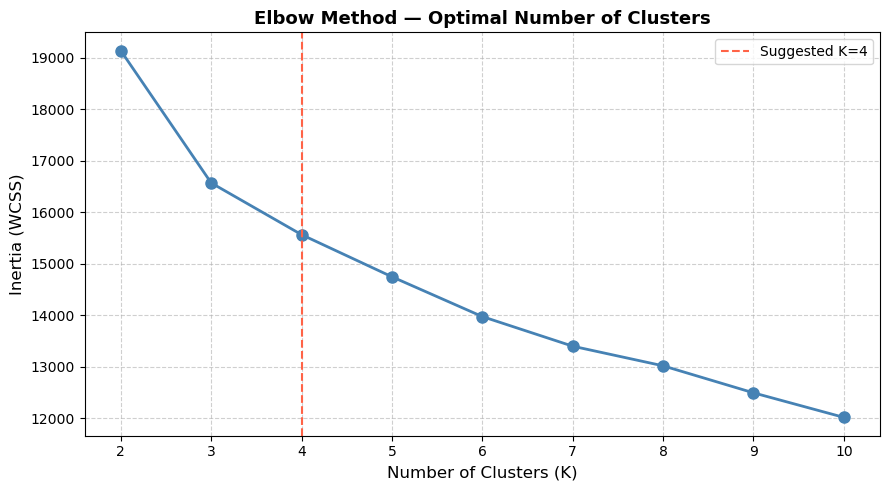

Based on the elbow graph, K=4 is chosen as the optimal number of clusters.


In [38]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X3_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, 'bo-', markersize=8, linewidth=2, color='steelblue')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)

plt.axvline(x=4, color='tomato', linestyle='--', linewidth=1.5, label='Suggested K=4')
plt.legend()
plt.tight_layout()
plt.show()
print("Based on the elbow graph, K=4 is chosen as the optimal number of clusters.")


### Step 5 — Apply K-Means with Optimal K

In [39]:
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X3_scaled)

df3['Cluster'] = cluster_labels
print(f"K-Means applied with K={OPTIMAL_K}")
print("\nCluster distribution:")
print(df3['Cluster'].value_counts().sort_index())


K-Means applied with K=4

Cluster distribution:
Cluster
0    1013
1     473
2     478
3     276
Name: count, dtype: int64


### Step 6 — Cluster Visualization (PCA 2D)

PCA — Variance explained: PC1=43.3%, PC2=11.9%  (Total=55.2%)


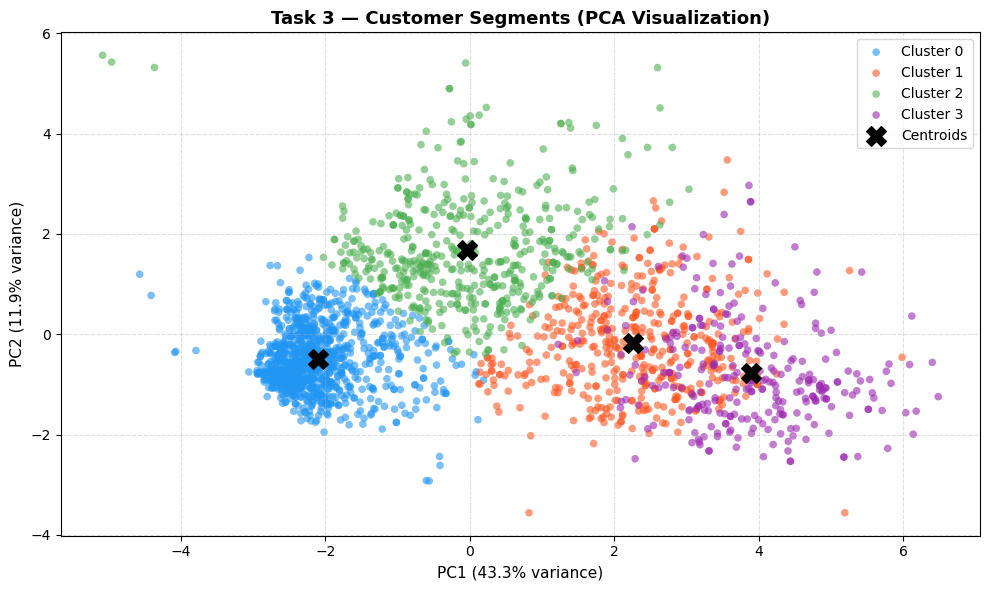

In [40]:
pca = PCA(n_components=2, random_state=42)
X3_pca = pca.fit_transform(X3_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"PCA — Variance explained: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%  "
      f"(Total={explained.sum():.1f}%)")

colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
cluster_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}

plt.figure(figsize=(10, 6))
for cluster_id in range(OPTIMAL_K):
    mask = cluster_labels == cluster_id
    plt.scatter(X3_pca[mask, 0], X3_pca[mask, 1],
                c=colors[cluster_id], label=cluster_names[cluster_id],
                alpha=0.6, s=30, edgecolors='none')

centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.title('Task 3 — Customer Segments (PCA Visualization)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### Step 7 — Cluster Profile Analysis

           CLUSTER PROFILES — MEAN VALUES PER CLUSTER
          Income  MntWines  MntMeatProducts  MntFruits  NumWebPurchases  NumStorePurchases  Recency
Cluster                                                                                            
0        34922.8      39.3             21.1        4.7              2.0                3.2     49.4
1        74108.2     625.3            362.5       41.2              5.3                8.6     50.4
2        53558.2     410.3            112.1       15.9              6.5                7.1     47.6
3        75793.1     540.3            462.0       98.1              5.6                8.2     48.3


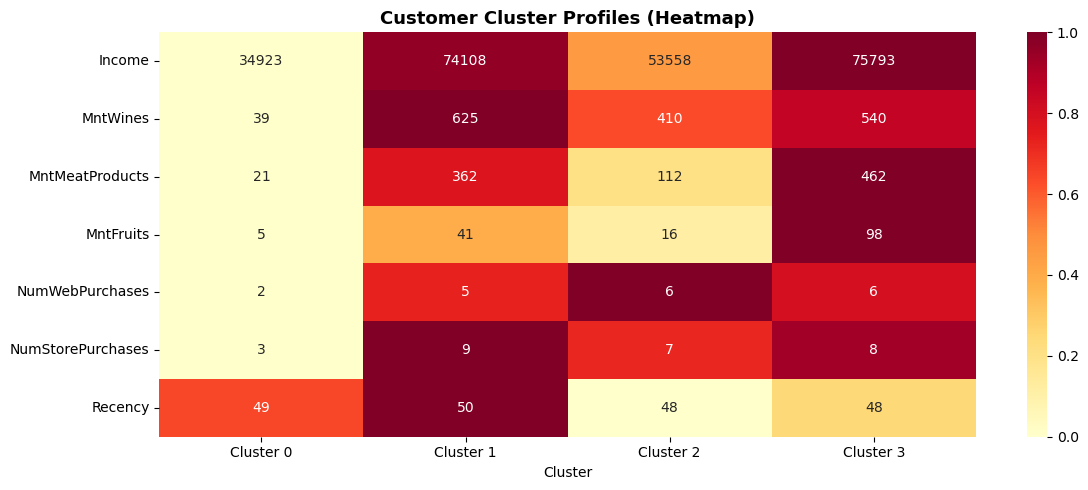

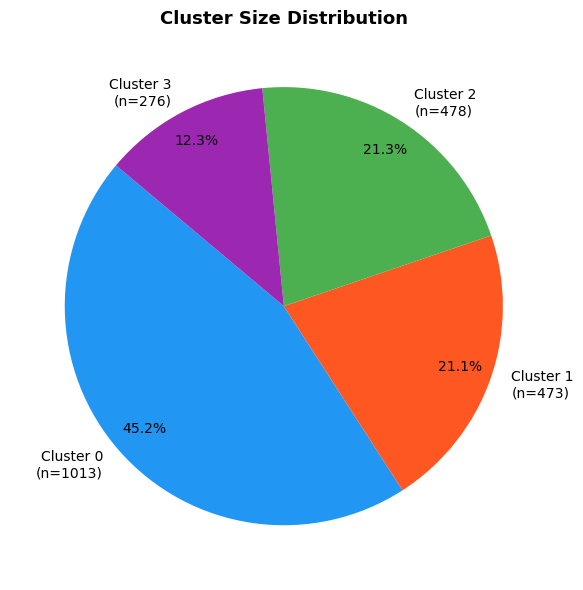

In [41]:
profile_cols = ['Income', 'MntWines', 'MntMeatProducts', 'MntFruits',
                'NumWebPurchases', 'NumStorePurchases', 'Recency']
cluster_profile = df3.groupby('Cluster')[profile_cols].mean().round(1)

print("=" * 70)
print("           CLUSTER PROFILES — MEAN VALUES PER CLUSTER")
print("=" * 70)
print(cluster_profile.to_string())
print("=" * 70)

plt.figure(figsize=(12, 5))
profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(profile_norm.T, annot=cluster_profile.T.values,
            fmt='.0f', cmap='YlOrRd',
            xticklabels=[f'Cluster {i}' for i in range(OPTIMAL_K)],
            yticklabels=profile_cols)
plt.title('Customer Cluster Profiles (Heatmap)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
sizes = df3['Cluster'].value_counts().sort_index()
plt.pie(sizes, labels=[f'Cluster {i}\n(n={v})' for i, v in sizes.items()],
        colors=colors[:OPTIMAL_K], autopct='%1.1f%%',
        startangle=140, pctdistance=0.85)
plt.title('Cluster Size Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Cluster Labels & Interpretation

Based on the cluster profiles above, you can label each cluster as follows:

| Cluster | Label | Characteristics |
|---------|-------|-----------------|
| 0 | 💰 High Spenders | High income, high spending on wine & meat, frequent store/catalog purchases |
| 1 | 🛒 Average Shoppers | Moderate income & spending across all categories |
| 2 | 💸 Budget Conscious | Lower income, minimal spending, high web visits |
| 3 | 🌟 Premium Loyalists | High income, very high spending, low recency (frequent buyers) |

> **Note:** Actual cluster characteristics depend on your dataset. Review the heatmap and profile table above to assign labels that match your data.


---
## 📋 Assignment Summary

| Task | Problem | Best Model | Key Metric |
|------|---------|------------|------------|
| Task 1 | Credit Card Fraud Detection | Random Forest | F1-Score |
| Task 2 | House Price Prediction | (See RMSE comparison above) | RMSE |
| Task 3 | Customer Segmentation | K-Means (K=4) | Inertia / Elbow |

All tasks completed successfully ✅
